# Fake Data Tests for Wiener-SVD Unfolding

- Only use MC stat and GENIE syst -- testing robustness of interaction uncertainties

In [11]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [ ]:
import pandas as pd
import numpy as np
from os import path, makedirs
from datetime import datetime

# local imports
import sys
sys.path.append('../../')
from pyanalib.split_df_helpers import *
from analysis_village.numucc_1p0pi.variable_configs import VariableConfig
from analysis_village.numucc_1p0pi.utils import *
from analysis_village.unfolding.wienersvd import *
from analysis_village.unfolding.unfolding_inputs import *

import matplotlib.pyplot as plt 
import matplotlib as mpl
plt.style.use("presentation.mplstyle")

import warnings
from pandas.errors import PerformanceWarning
warnings.filterwarnings("ignore", category=PerformanceWarning)

In [13]:
save_result = False
save_fig = save_result

save_fig_base_dir = "/exp/sbnd/data/users/munjung/plots/numucc1p0pi"
today_str = datetime.now().strftime("%Y%m%d")
save_fig_dir = path.join(save_fig_base_dir, "unfolding-fake_data_tests-{}".format(today_str))

if save_fig:
    if not path.exists(save_fig_dir):
        makedirs(save_fig_dir)
    print("saving plots in ", save_fig_dir)

# load dataframes

In [15]:
file_dir = "/exp/sbnd/data/users/munjung/xsec/2025Spring_v10_06_00_09"

## -- MC 
mc_file = path.join(file_dir, "MC", "BNB_cosmics", "aa_sel_mup-geniewgts.df")
mc_split_df = pd.read_hdf(mc_file, key="split")
mc_n_split = get_n_split(mc_file)
print("mc_n_split: %d" %(mc_n_split))
print_keys(mc_file)

n_max_concat = 3
mc_keys2load = ['hdr', "mcnu", 'evt'] 
mc_dfs = load_dfs(mc_file, mc_keys2load, n_max_concat=n_max_concat)
mc_hdr_df = mc_dfs['hdr']
mc_nu_df = mc_dfs['mcnu']
mc_evt_df = mc_dfs['evt']

mc_n_split: 1
Keys: ['/evt_0', '/hdr_0', '/histgenevtdf_0', '/histpotdf_0', '/mcnu_0', '/split']


In [16]:
## total pot
mc_tot_pot = mc_hdr_df['pot'].sum()
print("mc_tot_pot: %.3e" %(mc_tot_pot))

# target_pot = 1e20
target_pot = mc_tot_pot
mc_pot_scale = target_pot / mc_tot_pot
print("mc_pot_scale: %.3e" %(mc_pot_scale))

mc_evt_df["pot_weight"] = mc_pot_scale * np.ones(len(mc_evt_df))
mc_nu_df["pot_weight"] = mc_pot_scale * np.ones(len(mc_nu_df))

mc_tot_pot: 1.520e+19
mc_pot_scale: 1.000e+00


In [17]:
# add multiindex column index "mc" so that branch names match evt_df
# TODO: fix so I don't have to do this
mc_nu_df.columns = pd.MultiIndex.from_tuples([tuple(["mc"] + list(c)) for c in mc_nu_df.columns])     # match # of column levels

In [20]:
print("==== selected events ====")
mc_evt_df.loc[:,'nuint_categ'] = get_int_category(mc_evt_df, print_summary=True)
mc_evt_df.loc[:,'genie_categ'] = get_genie_category(mc_evt_df, print_summary=True)

print("==== all events ====")
mc_nu_df.loc[:,'nuint_categ'] = get_int_category(mc_nu_df, print_summary=True)
mc_nu_df.loc[:,'genie_categ'] = get_genie_category(mc_nu_df, print_summary=True)

==== selected events ====
 1    3074
 2      98
 3      92
 4      44
-1      25
 5       6
 0       2
Name: count, dtype: int64
 1    2759
 2     386
 3     113
 6      44
-1      25
 7       6
 4       5
 0       2
 5       1
Name: count, dtype: int64
==== all events ====
0    218890
3     47554
4     26447
2      8921
1      8230
5       978
Name: count, dtype: int64
0    218890
1     34191
6     26447
3     18368
2      8590
4      3432
7       978
5       124
Name: count, dtype: int64


# Constants

['flux_sbnd_numu;1', 'flux_sbnd_nue;1', 'flux_sbnd_anumu;1', 'flux_sbnd_anue;1']
Integrated flux: 2.454e+11
# of targets:  1.3251484770937053e+30
xsec unit:  3.0748553153882176e-42


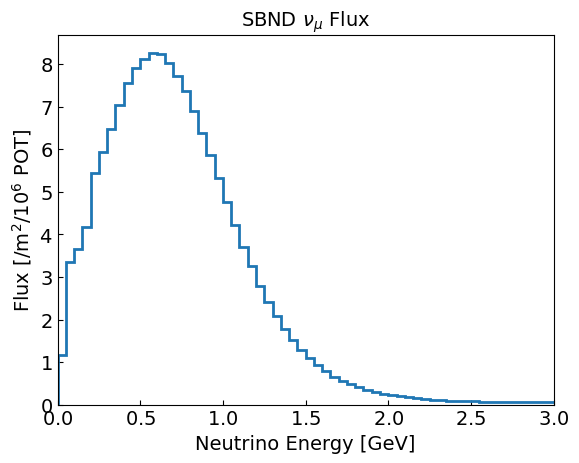

In [21]:
import uproot

# TODO: z-dependence?
# flux file, units: /m^2/10^6 POT 
# 50 MeV bins
fluxfile = "/exp/sbnd/data/users/munjung/flux/sbnd_original_flux.root"
flux = uproot.open(fluxfile)
print(flux.keys())
numu_flux = flux["flux_sbnd_numu"].to_numpy()
bin_edges = numu_flux[1]
flux_vals = numu_flux[0]

fig, ax = plt.subplots()
plt.hist(bin_edges[:-1], bins=bin_edges, weights=flux_vals, histtype="step", linewidth=2, color="C0")
plt.xlim(0, 3)
plt.xlabel("Neutrino Energy [GeV]")
plt.ylabel("Flux [/m$^{2}$/10$^{6}$ POT]")
plt.title("SBND $\\nu_\\mu$ Flux")


# get integrated flux
integrated_flux = flux_vals.sum()
integrated_flux /= 1e4 # to cm2
INTEGRATED_FLUX = integrated_flux * mc_tot_pot / 1e6 # POT
print("Integrated flux: %.3e" % INTEGRATED_FLUX)

V_SBND = 380 * 380 * 440 # cm3, the active volume of the detector 
NTARGETS = RHO * V_SBND * N_A / M_AR
print("# of targets: ", NTARGETS)

# TODO: fix scalar overflow error
XSEC_UNIT = 1 / (INTEGRATED_FLUX * NTARGETS)
print("xsec unit: ", XSEC_UNIT)
if XSEC_UNIT == 0:
    XSEC_UNIT = 1e-38

# Choose variable

In [22]:
var_config = VariableConfig.muon_momentum()

# Systematic Uncertainties

In [28]:
file_dir = "/exp/sbnd/data/users/munjung/xsec/2025Spring_v10_06_00_09"
mcstat_syst = np.load(file_dir + "/mcstat_syst_dict.npz")
flux_syst = np.load(file_dir + "/flux_syst_dict.npz")
g4_syst = np.load(file_dir + "/g4_syst_dict.npz")
cosmics_syst = np.load(file_dir + "/cosmics_syst_dict.npz")
genie_syst = np.load(file_dir + "/genie_syst_dict.npz")

file_dir = "/exp/sbnd/data/users/munjung/xsec/2025Spring_v10_06_00_10"
detvar_syst = np.load(file_dir + "/detvar_syst_dict.npz")

# flat uncertainties
pot_frac_unc = 0.01
ntargets_frac_unc = 0.01

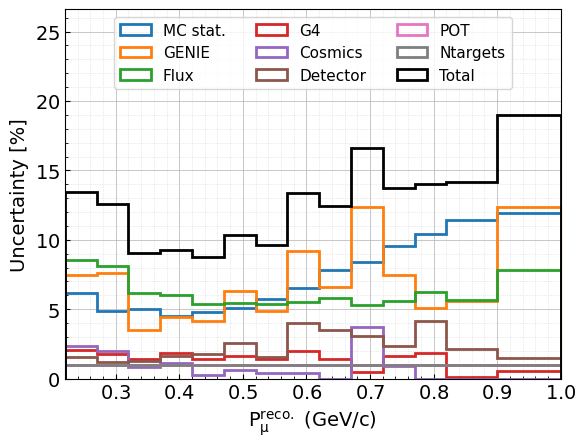

In [29]:
fig, ax = plt.subplots()

frac_uncert_total = np.zeros(len(var_config.bin_centers))

# systs with covariance
systs      = [mcstat_syst, genie_syst, flux_syst, g4_syst, cosmics_syst, detvar_syst]
syst_names = ["MC stat.", "GENIE", "Flux", "G4", "Cosmics", "Detector"]
# flat systs
flat_systs = [pot_frac_unc, ntargets_frac_unc]
flat_syst_names = ["POT", "Ntargets"]

for syst_name, syst in zip(syst_names, systs):
    syst_uncert = np.sqrt(np.diag(syst[var_config.var_save_name]))
    frac_uncert_total += syst_uncert ** 2
    plt.hist(var_config.bin_centers, bins=var_config.bins, weights=syst_uncert * 1e2,   histtype="step", linewidth=2, label=syst_name)

for syst_name, syst in zip(flat_syst_names, flat_systs):
    syst_uncert = syst * np.ones(len(var_config.bin_centers))
    frac_uncert_total += syst_uncert ** 2
    plt.hist(var_config.bin_centers, bins=var_config.bins, weights=syst_uncert * 1e2,   histtype="step", linewidth=2, label=syst_name)

frac_uncert_total = np.sqrt(frac_uncert_total)
plt.hist(var_config.bin_centers, bins=var_config.bins, weights=frac_uncert_total * 1e2,    histtype="step", linewidth=2, color="k",  label="Total")

plt.xlim(var_config.bins[0], var_config.bins[-1])
plt.ylim(0, max(frac_uncert_total*1e2) * 1.4)

plt.xlabel(var_config.var_labels[1])
plt.ylabel("Uncertainty [%]")
plt.legend(fontsize=11, ncol=3, loc="upper center")

plt.grid(which='major', linestyle='-', linewidth=0.7, alpha=0.7)
plt.grid(which='minor', linestyle=':', linewidth=0.5, alpha=0.5)
plt.minorticks_on()

if save_fig:
    plt.savefig("{}/uncertainty_breakdown-{}.pdf".format(save_fig_dir, var_config.var_save_name), bbox_inches='tight')
plt.show();

# Unfolding

In [54]:
# --- config for Wiener-SVD unfolding ---
C_type = 2
Norm_type = 0.5

## Closure test (Asimov data)
- use MC signal as fake data

In [55]:
eps = 1e-8
ratio = True
syst = True
approval = "internal"
textloc = [0.05, 0.55]
ax_ylim_ratio = 1.6
breakdown_type = "topology"

In [56]:
plot_labels_hist = [var_config.var_labels[1], "Events / Bin (POT={})".format(pot_str), ""]

No intime cosmics provided


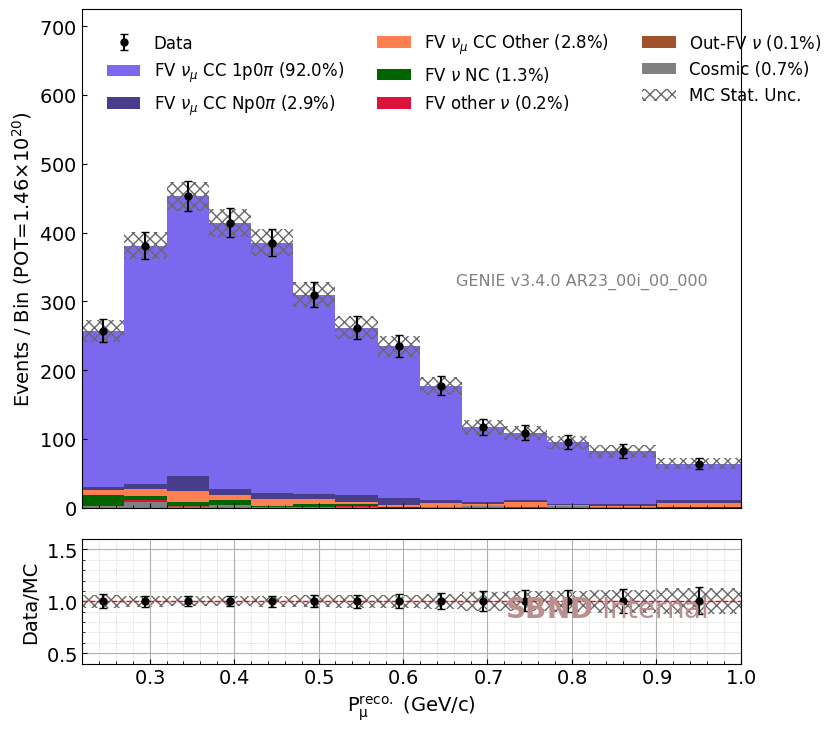

In [57]:
ret = overlay_hists(breakdown_type=breakdown_type,
                    mc_df=mc_evt_df,
                    data_df=mc_evt_df,
                    intime_df=None,
                    var_config=var_config,
                    plot_labels=plot_labels_hist,
                    ax_ylim_ratio=ax_ylim_ratio,
                    ratio=ratio,
                    syst=syst,
                    textloc=textloc,
                    approval=approval,
                    save_fig=save_fig, 
                    save_name=path.join(save_fig_dir, "{}_{}.png".format(var_config.var_save_name, breakdown_type)))

No pot_weight column found, return 1 as pot scale (expected for data)


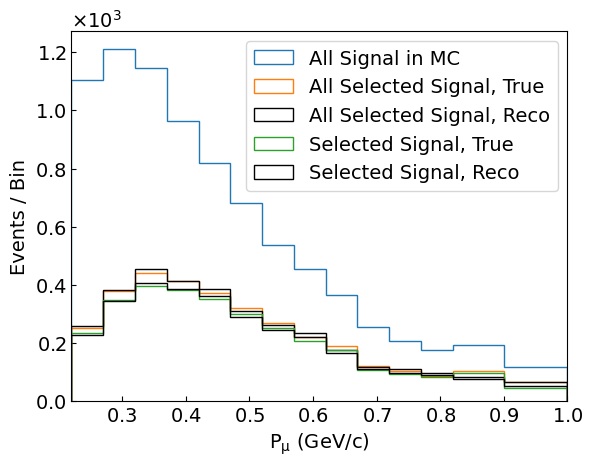

[[213.  21.   1.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.]
 [ 13. 308.  28.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.]
 [  0.  16. 348.  30.   1.   0.   0.   0.   0.   0.   0.   0.   0.   0.]
 [  0.   0.  27. 333.  22.   0.   0.   0.   0.   0.   0.   0.   0.   0.]
 [  0.   1.   1.  22. 308.  20.   0.   0.   0.   0.   0.   0.   0.   0.]
 [  0.   0.   1.   2.  29. 242.  26.   0.   0.   0.   0.   0.   0.   0.]
 [  0.   0.   0.   0.   3.  27. 196.  26.   0.   0.   0.   0.   0.   0.]
 [  0.   0.   0.   0.   0.   1.  21. 167.  16.   0.   0.   0.   0.   0.]
 [  0.   0.   0.   0.   0.   0.   0.  28. 132.  17.   0.   0.   0.   0.]
 [  0.   0.   0.   0.   0.   0.   0.   0.  17.  71.  20.   0.   0.   0.]
 [  0.   0.   0.   0.   0.   0.   0.   0.   0.  18.  56.  20.   0.   0.]
 [  0.   0.   0.   0.   0.   0.   0.   0.   1.   1.  20.  52.   8.   0.]
 [  0.   0.   1.   0.   0.   0.   0.   0.   0.   2.   2.  17.  63.  12.]
 [  0.   0.   0.   0.   0.   0.   0.   0.   0.   0.

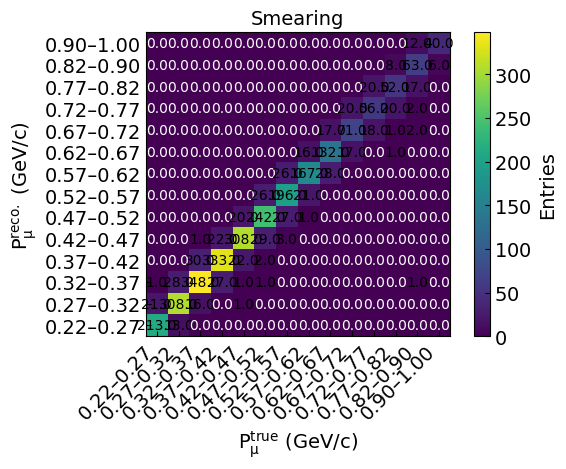

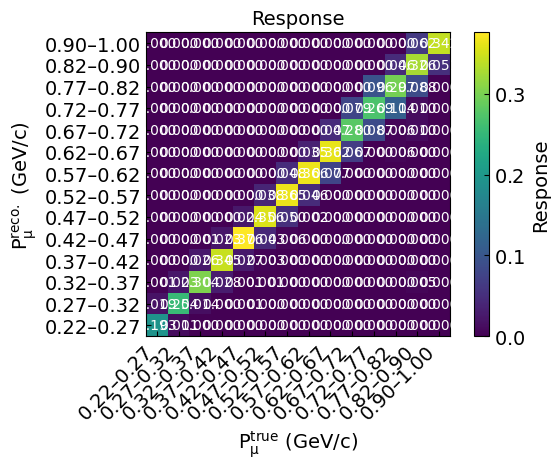

In [85]:
evtdf_signal = mc_evt_df[mc_evt_df.nuint_categ == 1]
nudf_signal = mc_nu_df[mc_nu_df.nuint_categ == 1]
ret = signal_hists(mc_evt_df, mc_nu_df, var_config, return_data=True, plot=False)

save_fig_name = "{}/{}-reco_vs_true".format(save_fig_dir, var_config.var_save_name)
reco_vs_true = get_smear_matrix(ret["var_sel_truth"], 
                                ret["var_sel_reco"], 
                                weights=ret["wgt_sel_reco"],
                                bins_2d=var_config.bins, 
                                var_labels=var_config.var_labels,
                                save_fig=save_fig, 
                                save_fig_name=save_fig_name)

eff = get_eff(reco_vs_true, ret["nevts_allmc"])

save_fig_name = "{}/{}-response_matrix".format(save_fig_dir, var_config.var_save_name)
response = get_response_matrix(reco_vs_true, 
                               eff, 
                               var_config.bins, 
                               var_labels=var_config.var_labels,
                               save_fig=save_fig, 
                               save_fig_name=save_fig_name)

In [65]:
measured = ret["nevts_sel_reco"] * XSEC_UNIT 
model    = ret["nevts_allmc"] * XSEC_UNIT
Covariance = cov_from_fraccov(mcstat_syst[var_config.var_save_name], ret["nevts_sel_reco"]) * XSEC_UNIT**2
unfold = WienerSVD(response, model, measured, Covariance, C_type, Norm_type)
# print(unfold.keys())
# decomp_cov = Matrix_Decomp(model, unfold['SystUnfoldCov'])

[2.19276021e-81 2.33862126e-81 1.90573399e-81 1.45440270e-81
 1.22556140e-81 8.86558384e-82 5.16089550e-82 3.60715435e-82
 2.62525317e-82 1.48670966e-82 9.03092436e-83 5.97312947e-83
 6.22075417e-83 3.64550128e-83]


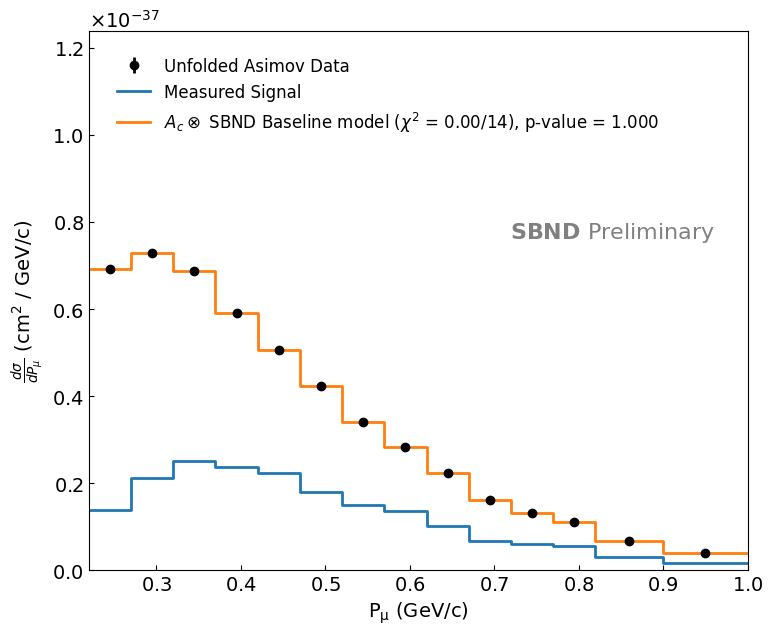

In [ ]:
models = {"SBND Baseline model": model}
save_name = "{}-closure_test_output.pdf".format(var_config.var_save_name)

plot_unfolded_result(unfold, 
                     measured, 
                     models, 
                     var_config,
                     save_fig=save_fig, 
                     save_name=save_name,
                     closure_test=True)

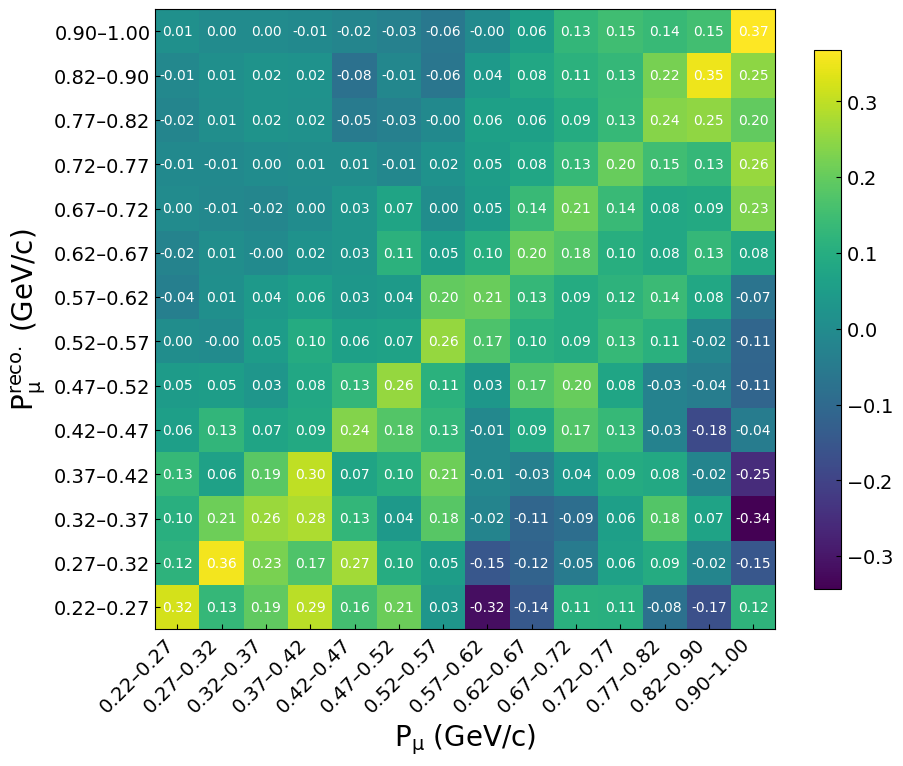

In [69]:
save_fig_name = "{}/{}-{}-add_smear".format(save_fig_dir, var_config.var_save_name, "closure_test")
plot_heatmap(unfold["AddSmear"], 
             var_config, 
             "",
             save_fig=save_fig, 
             save_fig_name=save_fig_name)

## Fake Data Tests

- use alternate MC as fake data

In [70]:
# use only stat unc and xsec unc for fake data tests
covariance_frac = genie_syst[var_config.var_save_name] + mcstat_syst[var_config.var_save_name]
covariance = cov_from_fraccov(covariance_frac, ret["nevts_sel_reco"]) * XSEC_UNIT**2

In [71]:
unfolded_plot_labels = [var_config.var_labels[0], var_config.xsec_label]
smearmat_plot_labels = [var_config.var_labels[2], var_config.var_labels[1]]

In [72]:
class FakeDataWeights:
    def __init__(self, mc_evt_df, mc_nu_df, var_config):
        self.mc_evt_df = mc_evt_df
        self.mc_nu_df = mc_nu_df
        self.var_config = var_config

    def get_weights(self, test_name, **kwargs):
        # Always start from ones (unless otherwise needed)
        # TODO: place normalization here?
        weights_fake_data = np.ones(len(self.mc_evt_df))
        weight_fakedata_signal_truth = np.ones(len(self.mc_nu_df[self.mc_nu_df.nuint_categ == 1]))
        
        # MEC normalization
        if test_name == "mec_test":
            scale_factor = kwargs.get("scale_factor", 0.5)
            weights_fake_data[self.mc_evt_df.mc.genie_mode == 10] *= scale_factor
            weight_fakedata_signal_truth[self.mc_nu_df[self.mc_nu_df.nuint_categ == 1].mc.genie_mode == 10] *= scale_factor

        # QE normalization
        elif test_name == "qe_test":
            scale_factor = kwargs.get("scale_factor", 1.2)
            weights_fake_data[self.mc_evt_df.mc.genie_mode == 0] *= scale_factor
            weight_fakedata_signal_truth[self.mc_nu_df[self.mc_nu_df.nuint_categ == 1].mc.genie_mode == 0] *= scale_factor

        # np normalization
        elif test_name == "np_test":
            Np_scale = kwargs.get("Np_scale", 2)
            weights_fake_data[self.mc_evt_df.nuint_categ == 2] *= Np_scale
            weight_fakedata_signal_truth[self.mc_nu_df[self.mc_nu_df.nuint_categ == 1].nuint_categ == 2] *= Np_scale

        # sig normalization
        elif test_name == "sig_test":
            sig_scale = kwargs.get("sig_scale", 1.2)
            weights_fake_data[self.mc_evt_df.nuint_categ == 1] *= sig_scale
            weight_fakedata_signal_truth[self.mc_nu_df[self.mc_nu_df.nuint_categ == 1].nuint_categ == 1] *= sig_scale

        # Q2 tilt
        elif test_name.startswith("q2_test_alpha_"):
            alpha = kwargs.get("alpha", 0.3)
            Q2 = 2 * self.mc_evt_df.mc.E * self.mc_evt_df.mu.pfp.trk.truth.p.startE * (1 - self.mc_evt_df.mu.pfp.trk.truth.p.dir.z)
            weights_fake_data *= np.ones(len(self.mc_evt_df)) + alpha * (Q2 - Q2.mean())/Q2.mean()
            weights_fake_data[np.isnan(weights_fake_data)] = 1
            assert np.isnan(weights_fake_data).sum() == 0
            Q2_nu = self.mc_nu_df[self.mc_nu_df.nuint_categ == 1].mc.Q2
            weight_fakedata_signal_truth *= np.ones(len(Q2_nu)) + alpha * (Q2_nu - Q2_nu.mean())/Q2_nu.mean()
        
        # cos(theta) scale
        elif test_name.startswith("costh_weight_scale_"):
            scale_factor = kwargs.get("scale_factor", 0.7)
            weights_fake_data[self.mc_evt_df.mu.pfp.trk.truth.p.dir.z > 0.9] *= scale_factor
            weight_fakedata_signal_truth[self.mc_nu_df[self.mc_nu_df.nuint_categ == 1].mc.mu.dir.z > 0.9] *= scale_factor

        # Proton P tilt
        elif test_name.startswith("proton_P_tilt_alpha_"):
            alpha = kwargs.get("alpha", 0.3)
            P_p_evt = self.mc_evt_df.p.pfp.trk.truth.p.totp
            weights_fake_data = np.ones(len(self.mc_evt_df)) + alpha * (P_p_evt - P_p_evt.mean())/P_p_evt.mean()
            P_p_nu = self.mc_nu_df[self.mc_nu_df.nuint_categ == 1].mc.p.totp
            weight_fakedata_signal_truth = np.ones(len(P_p_nu)) + alpha * (P_p_nu - P_p_nu.mean())/P_p_nu.mean()

        # Bump
        elif test_name.startswith("bump_"):
            bump_pos = kwargs.get("bump_pos", 0.6)
            bump_width = kwargs.get("bump_width", 0.0015)
            bump_height = kwargs.get("bump_height", 0.001)
            bump_height = bump_height*len(self.mc_evt_df)/len(self.var_config.bin_centers)
            bump_var_evt = self.mc_evt_df[self.var_config.var_evt_truth_col]
            weights_fake_data = np.ones(len(self.mc_evt_df)) + bump_height * np.exp(-0.5 * (bump_var_evt - bump_pos)**2 / bump_width**2)
            weights_fake_data[np.isnan(weights_fake_data)] = 1.
            bump_var_nu = self.mc_nu_df[self.mc_nu_df.nuint_categ == 1][self.var_config.var_nu_col]
            weight_fakedata_signal_truth = np.ones(len(bump_var_nu)) + bump_height * np.exp(-0.5 * (bump_var_nu - bump_pos)**2 / bump_width**2)
        
        # TODO
        # # Enhance tail
        # elif test_name.startswith("enhance_tail_alpha_"):
        #     alpha = kwargs.get("alpha", 0.7)
        #     weights_fake_data = np.ones(len(self.mc_evt_df))
        #     weights_fake_data[self.mc_evt_df.del_p > 0.25] = alpha
        #     weights_fake_data[np.isnan(weights_fake_data)] = 1.
        #     weight_fakedata_signal_truth = np.ones(len(self.mc_nu_df[self.mc_nu_df.nuint_categ == 1]))
        #     weight_fakedata_signal_truth[self.mc_nu_df[self.mc_nu_df.nuint_categ == 1].mc.del_p > 0.25] = alpha
        #     weight_fakedata_signal_truth[np.isnan(weight_fakedata_signal_truth)] = 1.

        else:
            raise ValueError(f"Unknown test_name '{test_name}' provided.")

        return weights_fake_data, weight_fakedata_signal_truth

In [74]:
# TODO: calculate this when making dfs
mc_evt_df[("mu","pfp","trk","truth","p","dir","z")] = mc_evt_df.mu.pfp.trk.truth.p.genp.z / mc_evt_df.mu.pfp.trk.truth.p.totp

In [88]:
fake_weight_obj = FakeDataWeights(mc_evt_df, mc_nu_df, var_config)

test_name = "mec_test"
scale_factor = 0.5
weights_fake_data, weight_fakedata_signal_truth = fake_weight_obj.get_weights(test_name, scale_factor=scale_factor)

# test_name = "qe_test"
# scale_factor = 1.2
# weights_fake_data, weight_fakedata_signal_truth = fake_weight_obj.get_weights(test_name, scale_factor=scale_factor)

# test_name = "np_test"
# Np_scale = 2
# weights_fake_data, weight_fakedata_signal_truth = fake_weight_obj.get_weights(test_name, Np_scale=Np_scale)

# test_name = "sig_test"
# sig_scale = 1.2
# weights_fake_data, weight_fakedata_signal_truth = fake_weight_obj.get_weights(test_name, sig_scale=sig_scale)

# test_name = "q2_test_alpha_0.3"
# alpha = 0.3
# weights_fake_data, weight_fakedata_signal_truth = fake_weight_obj.get_weights(test_name, alpha=alpha)

# test_name = "costh_weight_scale_0.7"
# scale_factor = 0.7
# weights_fake_data, weight_fakedata_signal_truth = fake_weight_obj.get_weights(test_name, scale_factor=scale_factor)

# test_name = "proton_P_tilt_alpha_0.3"
# alpha = 0.3
# weights_fake_data, weight_fakedata_signal_truth = fake_weight_obj.get_weights(test_name, alpha=alpha)

# test_name = "bump_0.6_0.0015_0.001"
# bump_pos = 0.6
# bump_width = 0.0015
# bump_height = 0.001
# weights_fake_data, weight_fakedata_signal_truth = fake_weight_obj.get_weights(test_name, bump_pos=bump_pos, bump_width=bump_width, bump_height=bump_height)

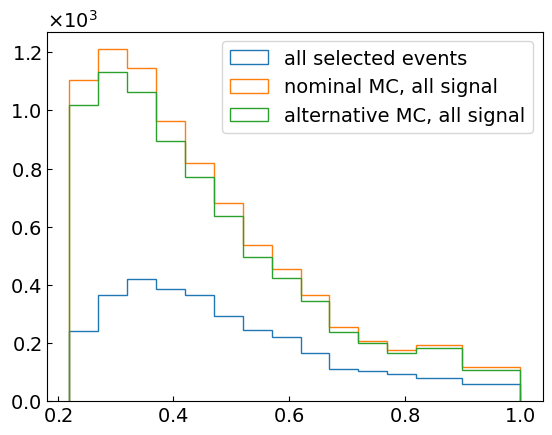

In [90]:
nevts_fakedata_reco, _ = np.histogram(ret["var_allsel_reco"], bins=var_config.bins, weights=weights_fake_data)
nevts_nomdata_signal_truth, _ = np.histogram(ret["var_allmc"], bins=var_config.bins)
nevts_fakedata_signal_truth, _ = np.histogram(ret["var_allmc"], bins=var_config.bins, weights=weight_fakedata_signal_truth)

fig, ax = plt.subplots()
plt.hist(var_config.bin_centers, var_config.bins, weights=nevts_fakedata_reco, histtype="step", label="all selected events")
plt.hist(var_config.bin_centers, var_config.bins, weights=nevts_nomdata_signal_truth, histtype="step", label="nominal MC, all signal")
plt.hist(var_config.bin_centers, var_config.bins, weights=nevts_fakedata_signal_truth, histtype="step", label="alternative MC, all signal")
plt.legend()
plt.show();

In [ ]:
fakedata_evt_df = mc_evt_df.copy()
fakedata_evt_df["pot_weight"] *= weights_fake_data

__ntuple  entry  rec.slc..index
16        3      0                 1.0
4         6      0                 1.0
0         12     0                 1.0
18        5      0                 1.0
15        9      2                 1.0
                                  ... 
10097     6      1                 1.0
10095     5      1                 1.0
          11     0                 0.5
10099     4      0                 1.0
10102     2      0                 1.0
Name: pot_weight, Length: 3341, dtype: float64

No intime cosmics provided


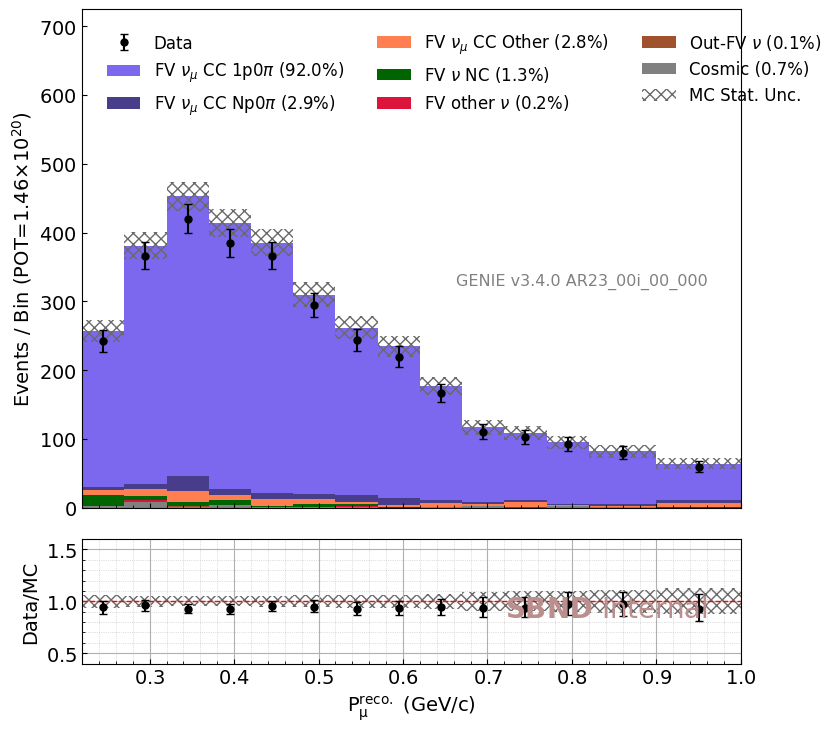

In [104]:
ret = overlay_hists(breakdown_type=breakdown_type,
                    mc_df=mc_evt_df,
                    data_df=fakedata_evt_df,
                    intime_df=None,
                    var_config=var_config,
                    plot_labels=plot_labels_hist,
                    ax_ylim_ratio=ax_ylim_ratio,
                    ratio=ratio,
                    syst=syst,
                    textloc=textloc,
                    approval=approval,
                    save_fig=save_fig, 
                    save_name=path.join(save_fig_dir, "{}_{}.png".format(var_config.var_save_name, breakdown_type)))

In [106]:
measured = (ret["total_data"] - ret["total_mc_bkgd"]) * XSEC_UNIT
model = nevts_nomdata_signal_truth * XSEC_UNIT
unfold = WienerSVD(response, model, measured, covariance, C_type, Norm_type)

[1.32548836e-80 1.29074293e-80 1.01450129e-80 7.08139240e-81
 4.74017671e-81 2.81469111e-81 1.14002774e-81 4.41976693e-82
 2.91218390e-82 2.05343160e-82 1.08372495e-82 7.77926177e-83
 1.10433054e-82 9.40343147e-83]


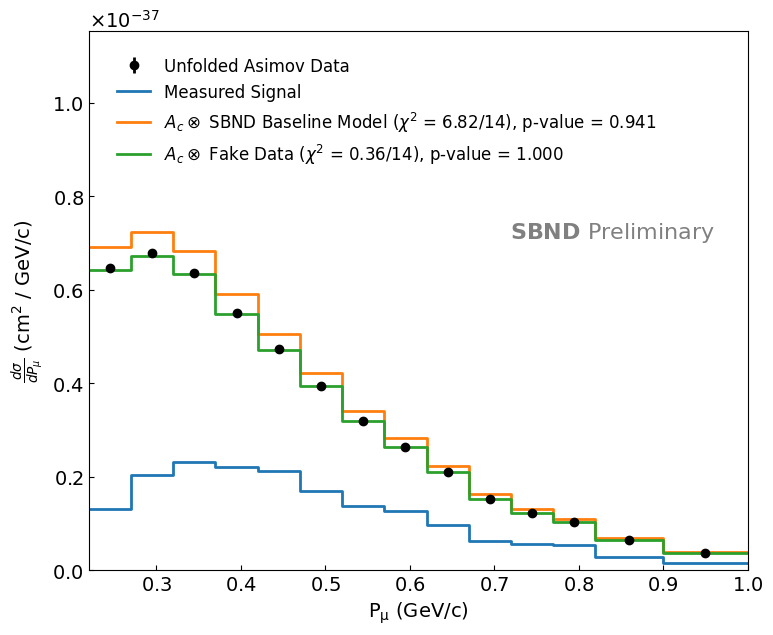

In [108]:
models = {"SBND Baseline Model": model, 
          "Fake Data": nevts_fakedata_signal_truth * XSEC_UNIT}
save_name = "{}/{}-{}-unfolded_event_rates.pdf".format(save_fig_dir, test_name, var_config.var_save_name)
plot_unfolded_result(unfold, 
                     measured, 
                     models, 
                     var_config,
                     save_fig=save_fig, 
                     save_name=save_name,
                     closure_test=True)

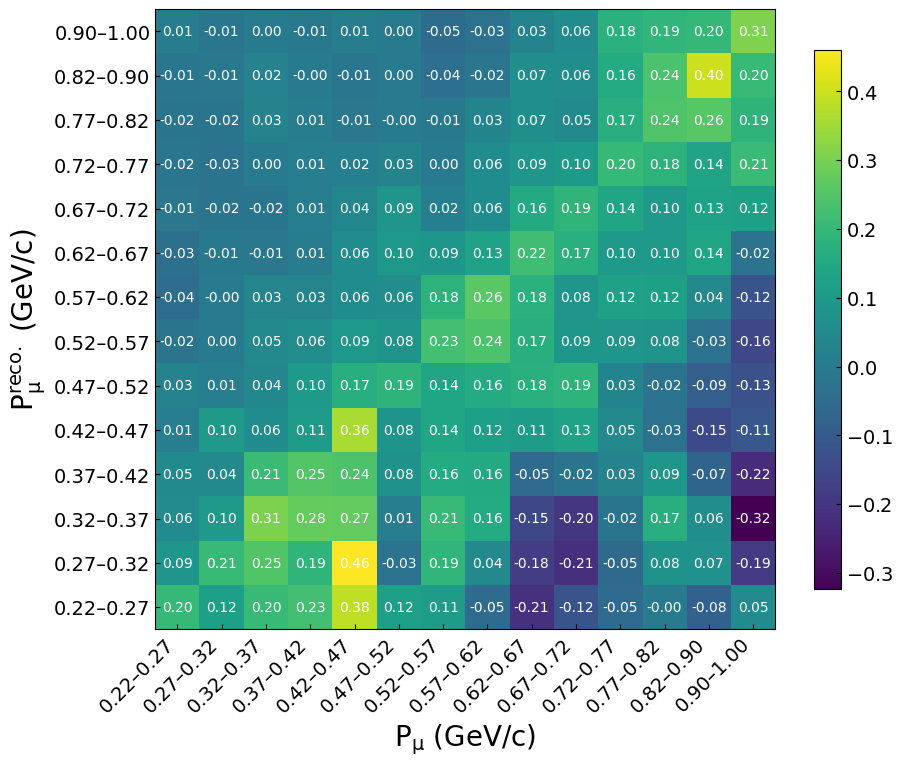

In [109]:
save_fig_name = "{}/{}-{}-add_smear".format(save_fig_dir, var_config.var_save_name, "closure_test")
plot_heatmap(unfold["AddSmear"], 
             var_config, 
             "",
             save_fig=save_fig, 
             save_fig_name=save_fig_name)

# Check distributions for fake data

## $Q^2$ reweight

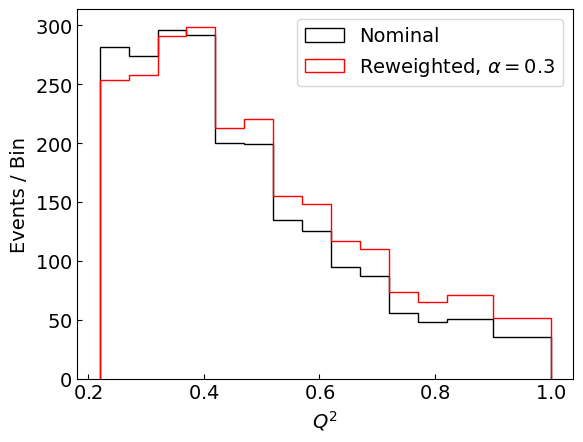

In [110]:
fake_weight_obj = FakeDataWeights(mc_evt_df, mc_nu_df, var_config)
Q2 = 2 * mc_evt_df.mc.E * mc_evt_df.mu.pfp.trk.truth.p.startE * (1 - mc_evt_df.mu.pfp.trk.truth.p.dir.z)
test_name = "q2_test_alpha_0.3"
alpha = 0.3
weights_fake_data, weight_fakedata_signal_truth = fake_weight_obj.get_weights(test_name, alpha=alpha)

plt.hist(Q2, bins=var_config.bins, histtype="step", color="black", label="Nominal")
plt.hist(Q2, bins=var_config.bins, weights=weights_fake_data, histtype="step", color="red", label="Reweighted, $\\alpha=${}".format(alpha))
plt.xlabel("$Q^2$")
plt.ylabel("Events / Bin")
plt.legend()
if save_fig:
    plt.savefig("{}/Q2_reweight_{}.pdf".format(save_fig_dir, alpha), bbox_inches="tight")
plt.show();